# 04c — CLEAR Local Peptide Variant Dataset

## Obiettivo

Costruire il dataset locale necessario per addestrare l’oracolo di **CLEAR** attorno al lead:

```text
F0010 — IGERCQYRDLK
```

Il notebook:

1. recupera il complesso F0010 dal 03c;
2. recupera hotspot e ΔΔG dal 02b;
3. classifica le posizioni in protette, conservative e mutabili;
4. genera seed, tutte le singole sostituzioni ammesse e un campione di doppie sostituzioni;
5. prepara FoldX `BuildModel` a blocchi riprendibili;
6. raccoglie ΔΔG, contatti, ritenzione degli hotspot e clash;
7. esporta il dataset per `04d_CLEAR_Peptide_Oracle_Training.ipynb`.

```text
03d → 04c dataset locale → 04d oracolo → 04e CLEAR
```

Il dataset è volutamente **locale**: CLEAR deve proporre modifiche minime e interpretabili, non una generazione indiscriminata.

## 1. Dipendenze

```bash
pip install pandas numpy matplotlib biopython
```

FoldX è richiesto soltanto per generare le label energetiche e i modelli mutanti.

In [1]:
from pathlib import Path
from itertools import combinations, product
import json, math, os, random, re, shutil, subprocess, time, warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from Bio.PDB import PDBParser, NeighborSearch, is_aa

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 180)
pd.set_option("display.max_colwidth", 180)
print("Ambiente inizializzato.")

Ambiente inizializzato.


## 2. Configurazione

Per una prima verifica della libreria lasciare `RUN_FOLDX = False`.  
Dopo il controllo, impostarlo a `True` e rieseguire dalla sezione FoldX.

In [17]:
SEED_FRAGMENT_ID = "F0010"
SEED_SEQUENCE = "IGERCQYRDLK"
PEPTIDE_CHAIN, RECEPTOR_CHAIN = "D", "B"
SEED_START_RESSEQ, SEED_END_RESSEQ = 38, 48

RANDOM_SEED = 20260805
MAX_DOUBLE_VARIANTS = 500
FOLDX_CHUNK_SIZE = 50
N_TOP_HOTSPOTS_PROTECTED = 2

ALLOW_PROLINE_INTRODUCTION = False
ALLOW_NEW_CYSTEINE = False
MAX_IDENTICAL_RUN = 3
MAX_ABS_NET_CHARGE = 5

RUN_FOLDX = True 
SKIP_COMPLETED_CHUNKS = True
BACKUP_INCOMPLETE_CHUNKS = True

CONTACT_CUTOFF_A = 4.5
CLASH_CUTOFF_A = 2.0

FOLDX_CANDIDATES = [
    shutil.which("foldx"),
    shutil.which("FoldX"),
    "/Users/robertobruzzese/Downloads/foldx5_MacSilicon_0/foldx",
    "/Users/robertobruzzese/Downloads/foldx5_MacSilicon_0/FoldX",
    "/Users/robertobruzzese/Downloads/foldx5_MacSilicon_0/foldx5.1_20261231",
]

OUTPUT_DIR = Path("outputs")
SOURCE_03C_DIR = OUTPUT_DIR / "short_peptide_guided_docking_03c"
SOURCE_03C_INPUT = SOURCE_03C_DIR / "rosetta_flexpepdock" / "inputs" / "F0010.pdb"
SOURCE_03C_RANKING = SOURCE_03C_DIR / "guided_docking_final_ranking.csv"
SOURCE_02B_INTERFACE = OUTPUT_DIR / "interface_residues_with_foldx_ddg.csv"
SOURCE_02B_HOTSPOTS = OUTPUT_DIR / "energetic_hotspots.csv"

DATASET_DIR = OUTPUT_DIR / "clear_local_peptide_dataset_04c"
LIBRARY_DIR = DATASET_DIR / "library"
FOLDX_DIR = DATASET_DIR / "foldx_buildmodel"
CHUNKS_DIR = FOLDX_DIR / "chunks"
MODELS_DIR = DATASET_DIR / "variant_models"
REPORTS_DIR = DATASET_DIR / "reports"

for d in [DATASET_DIR, LIBRARY_DIR, FOLDX_DIR, CHUNKS_DIR, MODELS_DIR, REPORTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("Seed:", SEED_SEQUENCE)
print("Output:", DATASET_DIR.resolve())

Seed: IGERCQYRDLK
Output: /Users/robertobruzzese/Desktop/venv/outputs/clear_local_peptide_dataset_04c


## 3. Recupero e validazione del complesso F0010

In [18]:
def resolve_f0010_pdb():
    candidates = [
        SOURCE_03C_INPUT,
        SOURCE_03C_DIR / "inputs" / "F0010_native_complex.pdb",
        OUTPUT_DIR / "short_peptide_structural_ranking" / "native_fragment_complexes" / "F0010_BD_D38-48.pdb",
    ]
    for p in candidates:
        if p.exists():
            return p.resolve()
    matches = [p for p in sorted(OUTPUT_DIR.rglob("F0010*.pdb"))
               if "best_poses" not in str(p) and "top5_poses" not in str(p)]
    if matches:
        return matches[0].resolve()
    raise FileNotFoundError("PDB nativo F0010 non trovato. Eseguire prima il 03c.")

NATIVE_F0010_PDB = resolve_f0010_pdb()
FOLDX_INPUT_PDB = FOLDX_DIR / "F0010_native_complex.pdb"
shutil.copy2(NATIVE_F0010_PDB, FOLDX_INPUT_PDB)

parser = PDBParser(QUIET=True)
AA3_TO_1 = {
    "ALA":"A","ARG":"R","ASN":"N","ASP":"D","CYS":"C","GLN":"Q","GLU":"E","GLY":"G",
    "HIS":"H","ILE":"I","LEU":"L","LYS":"K","MET":"M","PHE":"F","PRO":"P","SER":"S",
    "THR":"T","TRP":"W","TYR":"Y","VAL":"V",
}
def standard_residues(chain):
    return [r for r in chain if is_aa(r, standard=True)]
def sequence_from_chain(chain):
    return "".join(AA3_TO_1.get(r.get_resname().upper(),"X") for r in standard_residues(chain))

structure = parser.get_structure("F0010", str(NATIVE_F0010_PDB))
model = next(structure.get_models())
chains = [c.id for c in model]
if RECEPTOR_CHAIN not in chains or PEPTIDE_CHAIN not in chains:
    raise ValueError(f"Catene B e D richieste; trovate {chains}.")
observed = sequence_from_chain(model[PEPTIDE_CHAIN])
if observed != SEED_SEQUENCE:
    raise ValueError(f"Sequenza osservata {observed}, attesa {SEED_SEQUENCE}.")
print("PDB validato:", NATIVE_F0010_PDB)

PDB validato: /Users/robertobruzzese/Desktop/venv/outputs/short_peptide_guided_docking_03c/rosetta_flexpepdock/inputs/F0010.pdb


## 4. Recupero data-driven di hotspot e ΔΔG

In [19]:
def detect_column(columns, candidates):
    compact = {str(c).lower().replace(" ","").replace("_",""): c for c in columns}
    for name in candidates:
        k = name.lower().replace(" ","").replace("_","")
        if k in compact:
            return compact[k]
    for c in columns:
        cc = str(c).lower().replace(" ","").replace("_","")
        if any(name.lower().replace(" ","").replace("_","") in cc for name in candidates):
            return c
    return None

ddg_by_resseq, hotspot_resseqs = {}, set()

if SOURCE_02B_INTERFACE.exists():
    df = pd.read_csv(SOURCE_02B_INTERFACE)
    chain_col = detect_column(df.columns, ["chain","chain_id"])
    resseq_col = detect_column(df.columns, ["resseq","residue_number","position"])
    ddg_col = detect_column(df.columns, ["ddg","foldx_ddg","ddg_kcal_mol"])
    if resseq_col and ddg_col:
        if chain_col:
            df = df[df[chain_col].astype(str) == PEPTIDE_CHAIN]
        for _, r in df.iterrows():
            try:
                pos, val = int(r[resseq_col]), float(r[ddg_col])
            except Exception:
                continue
            if SEED_START_RESSEQ <= pos <= SEED_END_RESSEQ:
                ddg_by_resseq[pos] = val

if SOURCE_02B_HOTSPOTS.exists():
    df = pd.read_csv(SOURCE_02B_HOTSPOTS)
    chain_col = detect_column(df.columns, ["chain","chain_id"])
    resseq_col = detect_column(df.columns, ["resseq","residue_number","position"])
    if resseq_col:
        if chain_col:
            df = df[df[chain_col].astype(str) == PEPTIDE_CHAIN]
        for value in df[resseq_col]:
            try:
                pos = int(value)
            except Exception:
                continue
            if SEED_START_RESSEQ <= pos <= SEED_END_RESSEQ:
                hotspot_resseqs.add(pos)

if not hotspot_resseqs and SOURCE_03C_RANKING.exists():
    df = pd.read_csv(SOURCE_03C_RANKING)
    row = df[df["fragment_id"] == SEED_FRAGMENT_ID]
    if not row.empty:
        text = str(row.iloc[0].get("hotspot_positions",""))
        hotspot_resseqs = {int(x) for x in re.findall(r"(\d+)", text)
                           if SEED_START_RESSEQ <= int(x) <= SEED_END_RESSEQ}

print("Hotspot:", sorted(hotspot_resseqs))
print("ΔΔG:", ddg_by_resseq)

Hotspot: [39, 41, 43, 44, 45, 47]
ΔΔG: {45: 2.00281, 43: 2.51557, 40: 1.48925, 41: 5.73455, 39: 5.87659, 47: 3.54371, 44: 3.37068, 38: 1.41939, 48: 0.684765, 46: 0.0177372}


## 5. Classificazione delle posizioni e spazio delle sostituzioni

In [20]:
rows = []
for i, aa in enumerate(SEED_SEQUENCE, start=1):
    resseq = SEED_START_RESSEQ + i - 1
    rows.append({
        "sequence_position_1based": i,
        "chain": PEPTIDE_CHAIN,
        "resseq": resseq,
        "wildtype_aa": aa,
        "is_hotspot": resseq in hotspot_resseqs,
        "alanine_scan_ddG_kcal_mol": ddg_by_resseq.get(resseq, np.nan),
    })
positions_df = pd.DataFrame(rows)

hot = positions_df[positions_df["is_hotspot"]].copy()
if not hot.empty and hot["alanine_scan_ddG_kcal_mol"].notna().any():
    protected_resseqs = set(hot.sort_values("alanine_scan_ddG_kcal_mol", ascending=False)
                            .head(N_TOP_HOTSPOTS_PROTECTED)["resseq"].astype(int))
else:
    protected_resseqs = set(hot.sort_values("resseq").head(N_TOP_HOTSPOTS_PROTECTED)["resseq"].astype(int))
    if not hot.empty:
        warnings.warn("ΔΔG incompleti: hotspot protetti scelti per posizione.")

positions_df["position_class"] = positions_df.apply(
    lambda r: "protected_hotspot" if int(r["resseq"]) in protected_resseqs
    else ("conservative_hotspot" if bool(r["is_hotspot"]) else "mutable_non_hotspot"),
    axis=1,
)

CONSERVATIVE_MAP = {
    "A":set("GSVL"),"R":set("KHQ"),"N":set("QDST"),"D":set("EN"),"C":set("S"),
    "Q":set("NERT"),"E":set("DQN"),"G":set("AST"),"H":set("KRQN"),"I":set("LVMAT"),
    "L":set("IVMATF"),"K":set("RHQE"),"M":set("ILVAF"),"F":set("YWL"),"P":set("A"),
    "S":set("TANG"),"T":set("SANV"),"W":set("FY"),"Y":set("FWHT"),"V":set("ILMAT"),
}
EXTENDED_MAP = {k:set(v) for k,v in CONSERVATIVE_MAP.items()}
EXTENDED_MAP.update({
    "I":set("LVMATF"),"G":set("ASTNQ"),"E":set("DQNKR"),"R":set("KHQN"),
    "C":set("ST"),"Q":set("NERTK"),"Y":set("FWHTN"),"D":set("ENQ"),
    "L":set("IVMATF"),"K":set("RHQEN"),
})

def allowed_substitutions(wt, cls):
    if cls == "protected_hotspot":
        return set()
    allowed = set(CONSERVATIVE_MAP[wt] if cls == "conservative_hotspot" else EXTENDED_MAP[wt])
    allowed.discard(wt)
    if not ALLOW_PROLINE_INTRODUCTION:
        allowed.discard("P")
    if not ALLOW_NEW_CYSTEINE and wt != "C":
        allowed.discard("C")
    return allowed

positions_df["allowed_substitutions"] = positions_df.apply(
    lambda r: "".join(sorted(allowed_substitutions(r["wildtype_aa"], r["position_class"]))), axis=1)
positions_df["n_allowed_substitutions"] = positions_df["allowed_substitutions"].str.len()
display(positions_df)
print("Hotspot protetti:", sorted(protected_resseqs))

,sequence_position_1based,chain,resseq,wildtype_aa,is_hotspot,alanine_scan_ddG_kcal_mol,position_class,allowed_substitutions,n_allowed_substitutions
0,1,D,38,I,False,1.419390,mutable_non_hotspot,AFLMTV,6
1,2,D,39,G,True,5.876590,protected_hotspot,,0
2,3,D,40,E,False,1.489250,mutable_non_hotspot,DKNQR,5
3,4,D,41,R,True,5.734550,protected_hotspot,,0
4,5,D,42,C,False,NaN,mutable_non_hotspot,ST,2
5,6,D,43,Q,True,2.515570,conservative_hotspot,ENRT,4
6,7,D,44,Y,True,3.370680,conservative_hotspot,FHTW,4
7,8,D,45,R,True,2.002810,conservative_hotspot,HKQ,3
8,9,D,46,D,False,0.017737,mutable_non_hotspot,ENQ,3
9,10,D,47,L,True,3.543710,conservative_hotspot,AFIMTV,6


Hotspot protetti: [39, 41]


## 6. Funzioni di mutazione e descrittori

In [21]:
HYDROPHOBIC, AROMATIC = set("AILMFWVY"), set("FYW")
POSITIVE, NEGATIVE, POLAR = set("KRH"), set("DE"), set("STNQ")
STANDARD_AA = set("ACDEFGHIKLMNPQRSTVWY")

def apply_mutations(sequence, mutations):
    s = list(sequence)
    for m in mutations:
        idx = int(m["sequence_position_1based"]) - 1
        if s[idx] != m["wildtype_aa"]:
            raise ValueError("Wildtype inatteso.")
        s[idx] = m["mutant_aa"]
    return "".join(s)

def mutation_label(m):
    return f"{m['wildtype_aa']}{m['sequence_position_1based']}{m['mutant_aa']}"

def foldx_code(m):
    return f"{m['wildtype_aa']}{PEPTIDE_CHAIN}{m['resseq']}{m['mutant_aa']}"

def max_identical_run(seq):
    best = cur = 1
    for a,b in zip(seq,seq[1:]):
        cur = cur+1 if a==b else 1
        best = max(best,cur)
    return best

def sequence_descriptors(seq):
    n=len(seq)
    charge=sum(a in POSITIVE for a in seq)-sum(a in NEGATIVE for a in seq)
    return {
        "net_charge_proxy":charge,
        "hydrophobic_fraction":sum(a in HYDROPHOBIC for a in seq)/n,
        "aromatic_fraction":sum(a in AROMATIC for a in seq)/n,
        "polar_fraction":sum(a in POLAR for a in seq)/n,
        "positive_fraction":sum(a in POSITIVE for a in seq)/n,
        "negative_fraction":sum(a in NEGATIVE for a in seq)/n,
        "glycine_count":seq.count("G"),
        "proline_count":seq.count("P"),
        "cysteine_count":seq.count("C"),
        "max_identical_run":max_identical_run(seq),
    }

def sequence_passes_filters(seq):
    d=sequence_descriptors(seq)
    if set(seq)-STANDARD_AA: return False,"NON_STANDARD_AA"
    if d["max_identical_run"]>MAX_IDENTICAL_RUN: return False,"IDENTICAL_RUN"
    if abs(d["net_charge_proxy"])>MAX_ABS_NET_CHARGE: return False,"NET_CHARGE"
    if not ALLOW_PROLINE_INTRODUCTION and seq.count("P")>SEED_SEQUENCE.count("P"):
        return False,"NEW_PROLINE"
    if not ALLOW_NEW_CYSTEINE and seq.count("C")>SEED_SEQUENCE.count("C"):
        return False,"NEW_CYSTEINE"
    return True,"PASS"

## 7. Generazione delle varianti singole e doppie

In [22]:
single_records=[]
for r in positions_df.itertuples(index=False):
    for mut in r.allowed_substitutions:
        m={"sequence_position_1based":int(r.sequence_position_1based),"resseq":int(r.resseq),
           "wildtype_aa":r.wildtype_aa,"mutant_aa":mut,"is_hotspot":bool(r.is_hotspot),
           "position_class":r.position_class}
        seq=apply_mutations(SEED_SEQUENCE,[m])
        passed,reason=sequence_passes_filters(seq)
        single_records.append({
            "variant_type":"single","sequence":seq,"n_mutations":1,
            "mutation_labels":mutation_label(m),"foldx_mutation_string":foldx_code(m)+";",
            "mutated_sequence_positions":str(m["sequence_position_1based"]),
            "mutated_resseqs":str(m["resseq"]),"n_mutated_hotspots":int(m["is_hotspot"]),
            "all_mutations_conservative":mut in CONSERVATIVE_MAP[m["wildtype_aa"]],
            "filter_status":reason,"passes_filters":passed,
        })
single_variants=pd.DataFrame(single_records)

double_records=[]
mutable=positions_df[positions_df["n_allowed_substitutions"]>0]
for (_,a),(_,b) in combinations(mutable.iterrows(),2):
    for ma,mb in product(a["allowed_substitutions"], b["allowed_substitutions"]):
        muts=[
            {"sequence_position_1based":int(a["sequence_position_1based"]),"resseq":int(a["resseq"]),
             "wildtype_aa":a["wildtype_aa"],"mutant_aa":ma,"is_hotspot":bool(a["is_hotspot"])},
            {"sequence_position_1based":int(b["sequence_position_1based"]),"resseq":int(b["resseq"]),
             "wildtype_aa":b["wildtype_aa"],"mutant_aa":mb,"is_hotspot":bool(b["is_hotspot"])},
        ]
        if sum(int(m["is_hotspot"]) for m in muts)>1:
            continue
        seq=apply_mutations(SEED_SEQUENCE,muts)
        passed,reason=sequence_passes_filters(seq)
        if not passed: continue
        double_records.append({
            "variant_type":"double","sequence":seq,"n_mutations":2,
            "mutation_labels":";".join(mutation_label(m) for m in muts),
            "foldx_mutation_string":",".join(foldx_code(m) for m in muts)+";",
            "mutated_sequence_positions":";".join(str(m["sequence_position_1based"]) for m in muts),
            "mutated_resseqs":";".join(str(m["resseq"]) for m in muts),
            "n_mutated_hotspots":sum(int(m["is_hotspot"]) for m in muts),
            "all_mutations_conservative":all(m["mutant_aa"] in CONSERVATIVE_MAP[m["wildtype_aa"]] for m in muts),
            "filter_status":reason,"passes_filters":True,
        })
double_candidates=pd.DataFrame(double_records)

if len(double_candidates)>MAX_DOUBLE_VARIANTS:
    cons=double_candidates[double_candidates["all_mutations_conservative"]]
    other=double_candidates[~double_candidates["all_mutations_conservative"]]
    n_cons=min(int(MAX_DOUBLE_VARIANTS*.7),len(cons))
    chosen_cons=cons.sample(n=n_cons,random_state=RANDOM_SEED)
    pool=pd.concat([other,cons.drop(chosen_cons.index)],axis=0)
    chosen_other=pool.sample(n=min(MAX_DOUBLE_VARIANTS-n_cons,len(pool)),random_state=RANDOM_SEED+1)
    double_variants=pd.concat([chosen_cons,chosen_other],ignore_index=True)
else:
    double_variants=double_candidates.copy()

print("Singole valide:", int(single_variants["passes_filters"].sum()))
print("Doppie candidate:", len(double_candidates))
print("Doppie selezionate:", len(double_variants))

Singole valide: 38
Doppie candidate: 528
Doppie selezionate: 500


## 8. Libreria finale e controlli

In [23]:
seed_record={
    "variant_type":"seed","sequence":SEED_SEQUENCE,"n_mutations":0,"mutation_labels":"",
    "foldx_mutation_string":"","mutated_sequence_positions":"","mutated_resseqs":"",
    "n_mutated_hotspots":0,"all_mutations_conservative":True,
    "filter_status":"PASS","passes_filters":True,
}
library=pd.concat([
    pd.DataFrame([seed_record]),
    single_variants[single_variants["passes_filters"]],
    double_variants[double_variants["passes_filters"]],
],ignore_index=True).drop_duplicates("sequence").reset_index(drop=True)

library.insert(0,"variant_id",[f"V{i:05d}" for i in range(len(library))])
library=pd.concat([library,pd.DataFrame([sequence_descriptors(s) for s in library["sequence"]])],axis=1)
library["hamming_distance_from_seed"]=library["sequence"].apply(
    lambda s:sum(a!=b for a,b in zip(s,SEED_SEQUENCE)))

assert library["variant_id"].is_unique
assert library["sequence"].is_unique
assert library.iloc[0]["sequence"]==SEED_SEQUENCE
assert library["sequence"].str.len().eq(len(SEED_SEQUENCE)).all()
assert library["hamming_distance_from_seed"].le(2).all()

print("Varianti totali:",len(library))
display(library["variant_type"].value_counts().rename_axis("tipo").reset_index(name="n"))
display(library.head(20))

Varianti totali: 539


,tipo,n
0,double,500
1,single,38
2,seed,1


,variant_id,variant_type,sequence,n_mutations,mutation_labels,foldx_mutation_string,mutated_sequence_positions,mutated_resseqs,n_mutated_hotspots,all_mutations_conservative,filter_status,passes_filters,net_charge_proxy,hydrophobic_fraction,aromatic_fraction,polar_fraction,positive_fraction,negative_fraction,glycine_count,proline_count,cysteine_count,max_identical_run,hamming_distance_from_seed
0,V00000,seed,IGERCQYRDLK,0,,,,,0,True,PASS,True,1,0.272727,0.090909,0.090909,0.272727,0.181818,1,0,1,1,0
1,V00001,single,AGERCQYRDLK,1,I1A,ID38A;,1,38,0,True,PASS,True,1,0.272727,0.090909,0.090909,0.272727,0.181818,1,0,1,1,1
2,V00002,single,FGERCQYRDLK,1,I1F,ID38F;,1,38,0,False,PASS,True,1,0.272727,0.181818,0.090909,0.272727,0.181818,1,0,1,1,1
3,V00003,single,LGERCQYRDLK,1,I1L,ID38L;,1,38,0,True,PASS,True,1,0.272727,0.090909,0.090909,0.272727,0.181818,1,0,1,1,1
4,V00004,single,MGERCQYRDLK,1,I1M,ID38M;,1,38,0,True,PASS,True,1,0.272727,0.090909,0.090909,0.272727,0.181818,1,0,1,1,1
5,V00005,single,TGERCQYRDLK,1,I1T,ID38T;,1,38,0,True,PASS,True,1,0.181818,0.090909,0.181818,0.272727,0.181818,1,0,1,1,1
6,V00006,single,VGERCQYRDLK,1,I1V,ID38V;,1,38,0,True,PASS,True,1,0.272727,0.090909,0.090909,0.272727,0.181818,1,0,1,1,1
7,V00007,single,IGDRCQYRDLK,1,E3D,ED40D;,3,40,0,True,PASS,True,1,0.272727,0.090909,0.090909,0.272727,0.181818,1,0,1,1,1
8,V00008,single,IGKRCQYRDLK,1,E3K,ED40K;,3,40,0,False,PASS,True,3,0.272727,0.090909,0.090909,0.363636,0.090909,1,0,1,1,1
9,V00009,single,IGNRCQYRDLK,1,E3N,ED40N;,3,40,0,True,PASS,True,2,0.272727,0.090909,0.181818,0.272727,0.090909,1,0,1,1,1


## 9. Esportazione della libreria e dei vincoli CLEAR

In [24]:
LIBRARY_CSV=LIBRARY_DIR/"clear_local_variant_library.csv"
POSITIONS_CSV=LIBRARY_DIR/"clear_position_constraints.csv"
MUTATIONS_TXT=LIBRARY_DIR/"foldx_all_mutations.txt"
CONSTRAINTS_JSON=LIBRARY_DIR/"clear_constraints.json"

library.to_csv(LIBRARY_CSV,index=False)
positions_df.to_csv(POSITIONS_CSV,index=False)
foldx_library=library[library["n_mutations"]>0].copy()
MUTATIONS_TXT.write_text("\n".join(foldx_library["foldx_mutation_string"])+"\n",encoding="utf-8")

constraints={
    "seed_fragment_id":SEED_FRAGMENT_ID,"seed_sequence":SEED_SEQUENCE,
    "chain":PEPTIDE_CHAIN,"start_resseq":SEED_START_RESSEQ,"end_resseq":SEED_END_RESSEQ,
    "protected_resseqs":sorted(protected_resseqs),"hotspot_resseqs":sorted(hotspot_resseqs),
    "max_mutations":2,
    "position_constraints":positions_df[[
        "sequence_position_1based","resseq","wildtype_aa","is_hotspot",
        "position_class","allowed_substitutions"]].to_dict(orient="records"),
}
CONSTRAINTS_JSON.write_text(json.dumps(constraints,indent=2),encoding="utf-8")
print(LIBRARY_CSV.resolve())
print(CONSTRAINTS_JSON.resolve())

/Users/robertobruzzese/Desktop/venv/outputs/clear_local_peptide_dataset_04c/library/clear_local_variant_library.csv
/Users/robertobruzzese/Desktop/venv/outputs/clear_local_peptide_dataset_04c/library/clear_constraints.json


## 10. Preparazione dei blocchi FoldX

In [25]:
manifest_rows=[]
foldx_variants=library[library["n_mutations"]>0].reset_index(drop=True)
for chunk_num,start in enumerate(range(0,len(foldx_variants),FOLDX_CHUNK_SIZE),start=1):
    chunk=foldx_variants.iloc[start:start+FOLDX_CHUNK_SIZE].copy().reset_index(drop=True)
    chunk_id=f"chunk_{chunk_num:04d}"
    chunk_dir=CHUNKS_DIR/chunk_id
    chunk_dir.mkdir(parents=True,exist_ok=True)
    shutil.copy2(FOLDX_INPUT_PDB,chunk_dir/FOLDX_INPUT_PDB.name)
    (chunk_dir/"individual_list.txt").write_text(
        "\n".join(chunk["foldx_mutation_string"])+"\n",encoding="utf-8")
    chunk["foldx_local_index"]=np.arange(1,len(chunk)+1)
    chunk["chunk_id"]=chunk_id
    chunk["chunk_directory"]=str(chunk_dir)
    chunk.to_csv(chunk_dir/"chunk_manifest.csv",index=False)
    for r in chunk.itertuples(index=False):
        manifest_rows.append({
            "chunk_id":chunk_id,"foldx_local_index":int(r.foldx_local_index),
            "variant_id":r.variant_id,"sequence":r.sequence,
            "foldx_mutation_string":r.foldx_mutation_string,
            "chunk_directory":str(chunk_dir),
        })
chunk_manifest=pd.DataFrame(manifest_rows)
print("Blocchi:",chunk_manifest["chunk_id"].nunique())
print("Varianti FoldX:",len(chunk_manifest))
display(chunk_manifest.head())

Blocchi: 11
Varianti FoldX: 538


,chunk_id,foldx_local_index,variant_id,sequence,foldx_mutation_string,chunk_directory
0,chunk_0001,1,V00001,AGERCQYRDLK,ID38A;,outputs/clear_local_peptide_dataset_04c/foldx_buildmodel/chunks/chunk_0001
1,chunk_0001,2,V00002,FGERCQYRDLK,ID38F;,outputs/clear_local_peptide_dataset_04c/foldx_buildmodel/chunks/chunk_0001
2,chunk_0001,3,V00003,LGERCQYRDLK,ID38L;,outputs/clear_local_peptide_dataset_04c/foldx_buildmodel/chunks/chunk_0001
3,chunk_0001,4,V00004,MGERCQYRDLK,ID38M;,outputs/clear_local_peptide_dataset_04c/foldx_buildmodel/chunks/chunk_0001
4,chunk_0001,5,V00005,TGERCQYRDLK,ID38T;,outputs/clear_local_peptide_dataset_04c/foldx_buildmodel/chunks/chunk_0001


## 11. Individuazione ed esecuzione FoldX a blocchi riprendibili

In [28]:
FOLDX_EXECUTABLE = None

for candidate in FOLDX_CANDIDATES:
    if candidate and Path(candidate).exists():
        FOLDX_EXECUTABLE = str(Path(candidate).resolve())
        break

print("FoldX:", FOLDX_EXECUTABLE)


def numeric_suffix(path):
    match = re.search(r"_(\d+)\.pdb$", path.name)

    if match:
        return int(match.group(1))

    return 10**9


def get_mutant_pdbs(chunk_dir):
    """
    Restituisce soltanto i PDB mutanti prodotti da FoldX.

    Esclude:
    - il PDB di input;
    - i PDB wild-type con prefisso WT_;
    - eventuali PDB Repair.
    """
    return sorted(
        [
            path
            for path in chunk_dir.glob("*.pdb")
            if path.name != FOLDX_INPUT_PDB.name
            and not path.name.startswith("WT_")
            and "Repair" not in path.name
        ],
        key=numeric_suffix,
    )


def get_difference_files(chunk_dir):
    """
    FoldX può chiamare il file energetico:
    - Dif_*.fxout
    - DifferencesBetweenMutantAndWildType*.fxout
    """
    files = (
        list(chunk_dir.glob("Dif_*.fxout"))
        + list(
            chunk_dir.glob(
                "DifferencesBetweenMutantAndWildType*.fxout"
            )
        )
    )

    return sorted(set(files))


def chunk_status(chunk_id):
    d = CHUNKS_DIR / chunk_id
    manifest = pd.read_csv(d / "chunk_manifest.csv")

    mutant_pdbs = get_mutant_pdbs(d)
    difference_files = get_difference_files(d)

    complete = (
        len(mutant_pdbs) >= len(manifest)
        and len(difference_files) >= 1
    )

    return {
        "chunk_id": chunk_id,
        "n_variants": len(manifest),
        "n_mutant_pdbs": len(mutant_pdbs),
        "n_difference_files": len(difference_files),
        "complete": complete,
        "chunk_dir": str(d),
    }


initial_status = pd.DataFrame(
    [
        chunk_status(chunk_id)
        for chunk_id in sorted(
            chunk_manifest["chunk_id"].unique()
        )
    ]
)

display(initial_status)


if RUN_FOLDX and FOLDX_EXECUTABLE is None:
    raise FileNotFoundError(
        "RUN_FOLDX=True ma FoldX non è stato trovato."
    )


execution_rows = []

if RUN_FOLDX:
    chunk_ids = sorted(
        chunk_manifest["chunk_id"].unique()
    )

    for i, chunk_id in enumerate(
        chunk_ids,
        start=1,
    ):
        d = CHUNKS_DIR / chunk_id
        before = chunk_status(chunk_id)

        if (
            SKIP_COMPLETED_CHUNKS
            and before["complete"]
        ):
            print(
                f"[{i}/{len(chunk_ids)}] "
                f"{chunk_id}: già completo, salto."
            )

            execution_rows.append({
                **before,
                "status": "SKIPPED_ALREADY_COMPLETE",
                "returncode": 0,
                "elapsed_seconds": 0.0,
            })

            continue

        existing = [
            path
            for path in d.iterdir()
            if path.name not in {
                FOLDX_INPUT_PDB.name,
                "individual_list.txt",
                "chunk_manifest.csv",
            }
        ]

        if existing and BACKUP_INCOMPLETE_CHUNKS:
            backup = (
                d
                / (
                    "incomplete_backup_"
                    + time.strftime("%Y%m%d_%H%M%S")
                )
            )

            backup.mkdir(
                parents=True,
                exist_ok=True,
            )

            for path in existing:
                shutil.move(
                    str(path),
                    str(backup / path.name),
                )

        log = d / "foldx_buildmodel.log"

        cmd = [
            FOLDX_EXECUTABLE,
            "--command=BuildModel",
            f"--pdb={FOLDX_INPUT_PDB.name}",
            "--mutant-file=individual_list.txt",
            "--numberOfRuns=1",
        ]

        print()
        print(
            f"[{i}/{len(chunk_ids)}] "
            f"Avvio {chunk_id} — "
            f"{before['n_variants']} varianti"
        )

        start = time.time()

        with log.open(
            "w",
            encoding="utf-8",
        ) as fh:
            proc = subprocess.Popen(
                cmd,
                cwd=str(d),
                stdout=fh,
                stderr=subprocess.STDOUT,
                text=True,
            )

            while proc.poll() is None:
                n_mutants = len(
                    get_mutant_pdbs(d)
                )

                print(
                    f"  {chunk_id}: "
                    f"{n_mutants}/"
                    f"{before['n_variants']} PDB — "
                    f"{(time.time() - start) / 60:.1f} min",
                    end="\r",
                    flush=True,
                )

                time.sleep(15)

            rc = proc.wait()

        after = chunk_status(chunk_id)
        elapsed = time.time() - start

        print(
            f"  {chunk_id}: "
            f"{after['n_mutant_pdbs']}/"
            f"{after['n_variants']} PDB — "
            f"{elapsed / 60:.1f} min"
        )

        execution_rows.append({
            **after,
            "status": (
                "COMPLETED"
                if rc == 0 and after["complete"]
                else "FAILED_OR_INCOMPLETE"
            ),
            "returncode": int(rc),
            "elapsed_seconds": float(elapsed),
            "log_file": str(log),
        })

        if rc != 0 or not after["complete"]:
            tail = log.read_text(
                encoding="utf-8",
                errors="ignore",
            ).splitlines()[-30:]

            raise RuntimeError(
                f"{chunk_id} incompleto.\n"
                + "\n".join(tail)
            )

else:
    print(
        "RUN_FOLDX=False: blocchi preparati, "
        "nessuna esecuzione."
    )


foldx_execution_status = pd.DataFrame(
    execution_rows
)

if not foldx_execution_status.empty:
    display(foldx_execution_status)
                   

FoldX: /Users/robertobruzzese/Downloads/foldx5_MacSilicon_0/foldx5.1_20261231


,chunk_id,n_variants,n_mutant_pdbs,n_difference_files,complete,chunk_dir
0,chunk_0001,50,50,1,True,outputs/clear_local_peptide_dataset_04c/foldx_buildmodel/chunks/chunk_0001
1,chunk_0002,50,0,0,False,outputs/clear_local_peptide_dataset_04c/foldx_buildmodel/chunks/chunk_0002
2,chunk_0003,50,0,0,False,outputs/clear_local_peptide_dataset_04c/foldx_buildmodel/chunks/chunk_0003
3,chunk_0004,50,0,0,False,outputs/clear_local_peptide_dataset_04c/foldx_buildmodel/chunks/chunk_0004
4,chunk_0005,50,0,0,False,outputs/clear_local_peptide_dataset_04c/foldx_buildmodel/chunks/chunk_0005
5,chunk_0006,50,0,0,False,outputs/clear_local_peptide_dataset_04c/foldx_buildmodel/chunks/chunk_0006
6,chunk_0007,50,0,0,False,outputs/clear_local_peptide_dataset_04c/foldx_buildmodel/chunks/chunk_0007
7,chunk_0008,50,0,0,False,outputs/clear_local_peptide_dataset_04c/foldx_buildmodel/chunks/chunk_0008
8,chunk_0009,50,0,0,False,outputs/clear_local_peptide_dataset_04c/foldx_buildmodel/chunks/chunk_0009
9,chunk_0010,50,0,0,False,outputs/clear_local_peptide_dataset_04c/foldx_buildmodel/chunks/chunk_0010


[1/11] chunk_0001: già completo, salto.

[2/11] Avvio chunk_0002 — 50 varianti
  chunk_0002: 50/50 PDB — 5.3 min

[3/11] Avvio chunk_0003 — 50 varianti
  chunk_0003: 50/50 PDB — 5.8 min

[4/11] Avvio chunk_0004 — 50 varianti
  chunk_0004: 50/50 PDB — 6.5 min

[5/11] Avvio chunk_0005 — 50 varianti
  chunk_0005: 50/50 PDB — 6.0 min

[6/11] Avvio chunk_0006 — 50 varianti
  chunk_0006: 50/50 PDB — 6.0 min

[7/11] Avvio chunk_0007 — 50 varianti
  chunk_0007: 50/50 PDB — 6.0 min

[8/11] Avvio chunk_0008 — 50 varianti
  chunk_0008: 50/50 PDB — 6.8 min

[9/11] Avvio chunk_0009 — 50 varianti
  chunk_0009: 50/50 PDB — 8.5 min

[10/11] Avvio chunk_0010 — 50 varianti
  chunk_0010: 50/50 PDB — 8.0 min

[11/11] Avvio chunk_0011 — 38 varianti
  chunk_0011: 38/38 PDB — 6.0 min


,chunk_id,n_variants,n_mutant_pdbs,n_difference_files,complete,chunk_dir,status,returncode,elapsed_seconds,log_file
0,chunk_0001,50,50,1,True,outputs/clear_local_peptide_dataset_04c/foldx_buildmodel/chunks/chunk_0001,SKIPPED_ALREADY_COMPLETE,0,0.000000,NaN
1,chunk_0002,50,50,1,True,outputs/clear_local_peptide_dataset_04c/foldx_buildmodel/chunks/chunk_0002,COMPLETED,0,315.087697,outputs/clear_local_peptide_dataset_04c/foldx_buildmodel/chunks/chunk_0002/foldx_buildmodel.log
2,chunk_0003,50,50,1,True,outputs/clear_local_peptide_dataset_04c/foldx_buildmodel/chunks/chunk_0003,COMPLETED,0,345.160735,outputs/clear_local_peptide_dataset_04c/foldx_buildmodel/chunks/chunk_0003/foldx_buildmodel.log
3,chunk_0004,50,50,1,True,outputs/clear_local_peptide_dataset_04c/foldx_buildmodel/chunks/chunk_0004,COMPLETED,0,390.228005,outputs/clear_local_peptide_dataset_04c/foldx_buildmodel/chunks/chunk_0004/foldx_buildmodel.log
4,chunk_0005,50,50,1,True,outputs/clear_local_peptide_dataset_04c/foldx_buildmodel/chunks/chunk_0005,COMPLETED,0,360.232319,outputs/clear_local_peptide_dataset_04c/foldx_buildmodel/chunks/chunk_0005/foldx_buildmodel.log
5,chunk_0006,50,50,1,True,outputs/clear_local_peptide_dataset_04c/foldx_buildmodel/chunks/chunk_0006,COMPLETED,0,360.220789,outputs/clear_local_peptide_dataset_04c/foldx_buildmodel/chunks/chunk_0006/foldx_buildmodel.log
6,chunk_0007,50,50,1,True,outputs/clear_local_peptide_dataset_04c/foldx_buildmodel/chunks/chunk_0007,COMPLETED,0,360.167423,outputs/clear_local_peptide_dataset_04c/foldx_buildmodel/chunks/chunk_0007/foldx_buildmodel.log
7,chunk_0008,50,50,1,True,outputs/clear_local_peptide_dataset_04c/foldx_buildmodel/chunks/chunk_0008,COMPLETED,0,405.157560,outputs/clear_local_peptide_dataset_04c/foldx_buildmodel/chunks/chunk_0008/foldx_buildmodel.log
8,chunk_0009,50,50,1,True,outputs/clear_local_peptide_dataset_04c/foldx_buildmodel/chunks/chunk_0009,COMPLETED,0,510.211233,outputs/clear_local_peptide_dataset_04c/foldx_buildmodel/chunks/chunk_0009/foldx_buildmodel.log
9,chunk_0010,50,50,1,True,outputs/clear_local_peptide_dataset_04c/foldx_buildmodel/chunks/chunk_0010,COMPLETED,0,480.281174,outputs/clear_local_peptide_dataset_04c/foldx_buildmodel/chunks/chunk_0010/foldx_buildmodel.log


## 12. Stato finale FoldX e parsing delle energie

In [59]:
final_chunk_status = pd.DataFrame(
    [
        chunk_status(c)
        for c in sorted(
            chunk_manifest["chunk_id"].unique()
        )
    ]
)

display(final_chunk_status)


def parse_difference_file(path):
    records = []

    lines = Path(path).read_text(
        encoding="utf-8",
        errors="ignore",
    ).splitlines()

    for line in lines:
        s = line.strip()

        if not s or s.startswith("#"):
            continue

        low = s.lower()

        # Esclude la riga iniziale, ad esempio:
        # FoldX 5.1 (2011)
        if low.startswith("foldx "):
            continue

        # Esclude intestazioni o righe descrittive
        if (
            ("pdb" in low and "total" in low)
            or "backbone hbond" in low
        ):
            continue

        toks = [
            t
            for t in re.split(r"\t+|\s+", s)
            if t
        ]

        if len(toks) < 2:
            continue

        nums = []

        for t in toks[1:]:
            try:
                nums.append(float(t))
            except Exception:
                pass

        if not nums:
            continue

        records.append({
            "foldx_row_name": toks[0],
            "foldx_ddG_total_kcal_mol": nums[0],
            "foldx_raw_line": s,
        })

    return pd.DataFrame(records)


energy_rows = []
parse_diagnostics = []

for chunk_id in sorted(
    chunk_manifest["chunk_id"].unique()
):
    d = CHUNKS_DIR / chunk_id

    manifest = pd.read_csv(
        d / "chunk_manifest.csv"
    ).sort_values("foldx_local_index")

    # Funzione definita nella cella 11.
    # Cerca sia Dif_*.fxout sia
    # DifferencesBetweenMutantAndWildType*.fxout
    difference_files = get_difference_files(d)

    difference_file = (
        difference_files[-1]
        if difference_files
        else None
    )

    parsed = (
        parse_difference_file(difference_file)
        if difference_file is not None
        else pd.DataFrame()
    )

    row_count_ok = len(parsed) == len(manifest)

    parse_diagnostics.append({
        "chunk_id": chunk_id,
        "difference_file": (
            difference_file.name
            if difference_file is not None
            else "NESSUNO"
        ),
        "n_manifest_rows": len(manifest),
        "n_parsed_rows": len(parsed),
        "status": (
            "OK"
            if row_count_ok
            else "ROW_COUNT_MISMATCH"
        ),
    })

    print(
        chunk_id,
        "- file:",
        (
            difference_file.name
            if difference_file is not None
            else "NESSUNO"
        ),
        "- righe manifest:",
        len(manifest),
        "- righe parsed:",
        len(parsed),
    )

    for r in manifest.itertuples(index=False):
        idx = int(r.foldx_local_index) - 1

        if idx < len(parsed):
            pr = parsed.iloc[idx]

            energy_rows.append({
                "variant_id": r.variant_id,
                "chunk_id": chunk_id,
                "foldx_ddG_total_kcal_mol": float(
                    pr["foldx_ddG_total_kcal_mol"]
                ),
                "foldx_energy_parse_status":
                    "PARSED_BY_ORDER",
                "foldx_raw_line":
                    pr["foldx_raw_line"],
            })

        else:
            energy_rows.append({
                "variant_id": r.variant_id,
                "chunk_id": chunk_id,
                "foldx_ddG_total_kcal_mol": np.nan,
                "foldx_energy_parse_status":
                    "FILE_OR_ROW_MISSING",
                "foldx_raw_line": "",
            })


foldx_energies = pd.DataFrame(energy_rows)

foldx_parse_diagnostics = pd.DataFrame(
    parse_diagnostics
)


print("\nDiagnostica parsing:")

display(foldx_parse_diagnostics)


print("\nPrime energie:")

display(
    foldx_energies[
        [
            "variant_id",
            "chunk_id",
            "foldx_ddG_total_kcal_mol",
            "foldx_energy_parse_status",
            "foldx_raw_line",
        ]
    ].head(10)
)


print("\nStato parsing:")

display(
    foldx_energies[
        "foldx_energy_parse_status"
    ].value_counts(dropna=False)
)


print(
    "\nEnergie valide:",
    int(
        foldx_energies[
            "foldx_ddG_total_kcal_mol"
        ].notna().sum()
    ),
    "/",
    len(foldx_energies),
)


print(
    "Righe di intestazione FoldX "
    "erroneamente incluse:",
    int(
        foldx_energies["foldx_raw_line"]
        .astype(str)
        .str.startswith("FoldX ")
        .sum()
    ),
)

,chunk_id,n_variants,n_mutant_pdbs,n_difference_files,complete,chunk_dir
0,chunk_0001,50,50,1,True,outputs/clear_local_peptide_dataset_04c/foldx_buildmodel/chunks/chunk_0001
1,chunk_0002,50,50,1,True,outputs/clear_local_peptide_dataset_04c/foldx_buildmodel/chunks/chunk_0002
2,chunk_0003,50,50,1,True,outputs/clear_local_peptide_dataset_04c/foldx_buildmodel/chunks/chunk_0003
3,chunk_0004,50,50,1,True,outputs/clear_local_peptide_dataset_04c/foldx_buildmodel/chunks/chunk_0004
4,chunk_0005,50,50,1,True,outputs/clear_local_peptide_dataset_04c/foldx_buildmodel/chunks/chunk_0005
5,chunk_0006,50,50,1,True,outputs/clear_local_peptide_dataset_04c/foldx_buildmodel/chunks/chunk_0006
6,chunk_0007,50,50,1,True,outputs/clear_local_peptide_dataset_04c/foldx_buildmodel/chunks/chunk_0007
7,chunk_0008,50,50,1,True,outputs/clear_local_peptide_dataset_04c/foldx_buildmodel/chunks/chunk_0008
8,chunk_0009,50,50,1,True,outputs/clear_local_peptide_dataset_04c/foldx_buildmodel/chunks/chunk_0009
9,chunk_0010,50,50,1,True,outputs/clear_local_peptide_dataset_04c/foldx_buildmodel/chunks/chunk_0010


chunk_0001 - file: Dif_F0010_native_complex.fxout - righe manifest: 50 - righe parsed: 50
chunk_0002 - file: Dif_F0010_native_complex.fxout - righe manifest: 50 - righe parsed: 50
chunk_0003 - file: Dif_F0010_native_complex.fxout - righe manifest: 50 - righe parsed: 50
chunk_0004 - file: Dif_F0010_native_complex.fxout - righe manifest: 50 - righe parsed: 50
chunk_0005 - file: Dif_F0010_native_complex.fxout - righe manifest: 50 - righe parsed: 50
chunk_0006 - file: Dif_F0010_native_complex.fxout - righe manifest: 50 - righe parsed: 50
chunk_0007 - file: Dif_F0010_native_complex.fxout - righe manifest: 50 - righe parsed: 50
chunk_0008 - file: Dif_F0010_native_complex.fxout - righe manifest: 50 - righe parsed: 50
chunk_0009 - file: Dif_F0010_native_complex.fxout - righe manifest: 50 - righe parsed: 50
chunk_0010 - file: Dif_F0010_native_complex.fxout - righe manifest: 50 - righe parsed: 50
chunk_0011 - file: Dif_F0010_native_complex.fxout - righe manifest: 38 - righe parsed: 38

Diagnosti

,chunk_id,difference_file,n_manifest_rows,n_parsed_rows,status
0,chunk_0001,Dif_F0010_native_complex.fxout,50,50,OK
1,chunk_0002,Dif_F0010_native_complex.fxout,50,50,OK
2,chunk_0003,Dif_F0010_native_complex.fxout,50,50,OK
3,chunk_0004,Dif_F0010_native_complex.fxout,50,50,OK
4,chunk_0005,Dif_F0010_native_complex.fxout,50,50,OK
5,chunk_0006,Dif_F0010_native_complex.fxout,50,50,OK
6,chunk_0007,Dif_F0010_native_complex.fxout,50,50,OK
7,chunk_0008,Dif_F0010_native_complex.fxout,50,50,OK
8,chunk_0009,Dif_F0010_native_complex.fxout,50,50,OK
9,chunk_0010,Dif_F0010_native_complex.fxout,50,50,OK



Prime energie:


,variant_id,chunk_id,foldx_ddG_total_kcal_mol,foldx_energy_parse_status,foldx_raw_line
0,V00001,chunk_0001,0.463630,PARSED_BY_ORDER,F0010_native_complex_1.pdb\t0.46363\t0.346148\t1.02638\t0.711639\t-0.416927\t-1.00581\t0.999032\t0.0861055\t-1.51489\t0.265597\t0\t0\t0\t-0.0911063\t0.138896\t-0.0210033\t0\t0\...
1,V00002,chunk_0001,0.371447,PARSED_BY_ORDER,F0010_native_complex_2.pdb\t0.371447\t0.377605\t1.05869\t-0.181123\t0.49995\t-0.258039\t-0.429134\t-0.0251336\t-0.587722\t0.0633776\t0\t0\t0\t-0.144454\t-0.116356\t-0.00272559\...
2,V00003,chunk_0001,-0.033391,PARSED_BY_ORDER,F0010_native_complex_3.pdb\t-0.0333914\t-0.279508\t-0.300106\t-0.533883\t0.513429\t1.1222\t-0.527678\t0.181744\t0.355015\t-0.0665884\t0\t0\t0\t-0.502683\t0.17036\t0.00555312\t0...
3,V00004,chunk_0001,-0.310250,PARSED_BY_ORDER,F0010_native_complex_4.pdb\t-0.31025\t-0.0172325\t-0.0104792\t-0.551273\t0.110236\t0.617606\t-0.634628\t0.0257439\t0.639171\t0.195687\t0\t0\t0\t-0.713999\t0.148453\t0.00342027\...
4,V00005,chunk_0001,0.200212,PARSED_BY_ORDER,F0010_native_complex_5.pdb\t0.200212\t-0.169938\t-0.786697\t0.844637\t0.011369\t-1.01028\t1.43161\t-0.0578912\t-0.0350143\t-0.0505245\t0\t0\t0\t0.0308112\t-0.0699397\t0\t0\t0\t...
5,V00006,chunk_0001,0.567717,PARSED_BY_ORDER,F0010_native_complex_6.pdb\t0.567717\t0.0553056\t0\t0.604929\t0.00574896\t-0.605552\t0.963125\t-0.0559481\t-0.340312\t-0.0467339\t0\t0\t0\t-0.00556769\t-0.0680272\t0\t0\t0\t-5....
6,V00007,chunk_0001,1.062400,PARSED_BY_ORDER,F0010_native_complex_7.pdb\t1.0624\t0.82086\t1.22056\t0.371753\t-0.0492819\t-0.783952\t0.411617\t-0.0285463\t-0.895498\t0.0314139\t0\t0\t0\t-0.0286542\t-0.166888\t0.000122455\t...
7,V00008,chunk_0001,1.260970,PARSED_BY_ORDER,F0010_native_complex_8.pdb\t1.26097\t0.81375\t0.533783\t-0.0273511\t0.350987\t-0.0559498\t-0.168812\t0.0774346\t-0.310467\t0.090883\t0\t0\t0\t-0.0039854\t-0.0441686\t0.00284378...
8,V00009,chunk_0001,1.418710,PARSED_BY_ORDER,F0010_native_complex_9.pdb\t1.41871\t0.741303\t1.60136\t0.532413\t0.261208\t-1.37562\t0.603228\t-0.296717\t-0.798294\t0.289783\t0\t0\t0\t-0.105148\t-0.190657\t0.00353683\t0\t0\...
9,V00010,chunk_0001,0.593936,PARSED_BY_ORDER,F0010_native_complex_10.pdb\t0.593936\t0.2463\t0.602691\t0.00490441\t-0.0382574\t-0.36787\t0.0257262\t-0.000675276\t-0.0265394\t0.313727\t0\t0\t0\t-0.0263499\t0.0169536\t0.0029...



Stato parsing:


foldx_energy_parse_status
PARSED_BY_ORDER    538
Name: count, dtype: int64


Energie valide: 538 / 538
Righe di intestazione FoldX erroneamente incluse: 0


## 13. Associazione dei modelli FoldX ai variant ID

In [60]:
model_rows = []

for chunk_id in sorted(
    chunk_manifest["chunk_id"].unique()
):
    d = CHUNKS_DIR / chunk_id

    manifest = pd.read_csv(
        d / "chunk_manifest.csv"
    ).sort_values("foldx_local_index")

    # Recupera soltanto i PDB mutanti.
    # Esclude input, WT_ ed eventuali Repair.
    mutant_pdbs = get_mutant_pdbs(d)

    print(
        chunk_id,
        "- varianti manifest:",
        len(manifest),
        "- PDB mutanti:",
        len(mutant_pdbs),
    )

    if len(mutant_pdbs) != len(manifest):
        print(
            f"ATTENZIONE: {chunk_id} contiene "
            f"{len(mutant_pdbs)} PDB mutanti per "
            f"{len(manifest)} varianti."
        )

    for offset, r in enumerate(
        manifest.itertuples(index=False)
    ):
        if offset >= len(mutant_pdbs):
            model_rows.append({
                "variant_id": r.variant_id,
                "chunk_id": chunk_id,
                "foldx_local_index":
                    int(r.foldx_local_index),
                "source_model_pdb": "",
                "variant_model_pdb": "",
                "model_status": "MODEL_MISSING",
            })

            continue

        source_pdb = mutant_pdbs[offset]
        target_pdb = MODELS_DIR / f"{r.variant_id}.pdb"

        shutil.copy2(
            source_pdb,
            target_pdb,
        )

        model_rows.append({
            "variant_id": r.variant_id,
            "chunk_id": chunk_id,
            "foldx_local_index":
                int(r.foldx_local_index),
            "source_model_pdb": str(source_pdb),
            "variant_model_pdb": str(target_pdb),
            "model_status": "MODEL_AVAILABLE",
        })


model_manifest = pd.DataFrame(model_rows)

print("\nPrime associazioni variante-modello:")

display(
    model_manifest[
        [
            "variant_id",
            "chunk_id",
            "foldx_local_index",
            "source_model_pdb",
            "variant_model_pdb",
            "model_status",
        ]
    ].head(20)
)

print("\nStato dei modelli:")

display(
    model_manifest[
        "model_status"
    ].value_counts(dropna=False)
)

print(
    "\nModelli disponibili:",
    int(
        (
            model_manifest["model_status"]
            == "MODEL_AVAILABLE"
        ).sum()
    ),
    "/",
    len(model_manifest),
)

chunk_0001 - varianti manifest: 50 - PDB mutanti: 50
chunk_0002 - varianti manifest: 50 - PDB mutanti: 50
chunk_0003 - varianti manifest: 50 - PDB mutanti: 50
chunk_0004 - varianti manifest: 50 - PDB mutanti: 50
chunk_0005 - varianti manifest: 50 - PDB mutanti: 50
chunk_0006 - varianti manifest: 50 - PDB mutanti: 50
chunk_0007 - varianti manifest: 50 - PDB mutanti: 50
chunk_0008 - varianti manifest: 50 - PDB mutanti: 50
chunk_0009 - varianti manifest: 50 - PDB mutanti: 50
chunk_0010 - varianti manifest: 50 - PDB mutanti: 50
chunk_0011 - varianti manifest: 38 - PDB mutanti: 38

Prime associazioni variante-modello:


,variant_id,chunk_id,foldx_local_index,source_model_pdb,variant_model_pdb,model_status
0,V00001,chunk_0001,1,outputs/clear_local_peptide_dataset_04c/foldx_buildmodel/chunks/chunk_0001/F0010_native_complex_1.pdb,outputs/clear_local_peptide_dataset_04c/variant_models/V00001.pdb,MODEL_AVAILABLE
1,V00002,chunk_0001,2,outputs/clear_local_peptide_dataset_04c/foldx_buildmodel/chunks/chunk_0001/F0010_native_complex_2.pdb,outputs/clear_local_peptide_dataset_04c/variant_models/V00002.pdb,MODEL_AVAILABLE
2,V00003,chunk_0001,3,outputs/clear_local_peptide_dataset_04c/foldx_buildmodel/chunks/chunk_0001/F0010_native_complex_3.pdb,outputs/clear_local_peptide_dataset_04c/variant_models/V00003.pdb,MODEL_AVAILABLE
3,V00004,chunk_0001,4,outputs/clear_local_peptide_dataset_04c/foldx_buildmodel/chunks/chunk_0001/F0010_native_complex_4.pdb,outputs/clear_local_peptide_dataset_04c/variant_models/V00004.pdb,MODEL_AVAILABLE
4,V00005,chunk_0001,5,outputs/clear_local_peptide_dataset_04c/foldx_buildmodel/chunks/chunk_0001/F0010_native_complex_5.pdb,outputs/clear_local_peptide_dataset_04c/variant_models/V00005.pdb,MODEL_AVAILABLE
5,V00006,chunk_0001,6,outputs/clear_local_peptide_dataset_04c/foldx_buildmodel/chunks/chunk_0001/F0010_native_complex_6.pdb,outputs/clear_local_peptide_dataset_04c/variant_models/V00006.pdb,MODEL_AVAILABLE
6,V00007,chunk_0001,7,outputs/clear_local_peptide_dataset_04c/foldx_buildmodel/chunks/chunk_0001/F0010_native_complex_7.pdb,outputs/clear_local_peptide_dataset_04c/variant_models/V00007.pdb,MODEL_AVAILABLE
7,V00008,chunk_0001,8,outputs/clear_local_peptide_dataset_04c/foldx_buildmodel/chunks/chunk_0001/F0010_native_complex_8.pdb,outputs/clear_local_peptide_dataset_04c/variant_models/V00008.pdb,MODEL_AVAILABLE
8,V00009,chunk_0001,9,outputs/clear_local_peptide_dataset_04c/foldx_buildmodel/chunks/chunk_0001/F0010_native_complex_9.pdb,outputs/clear_local_peptide_dataset_04c/variant_models/V00009.pdb,MODEL_AVAILABLE
9,V00010,chunk_0001,10,outputs/clear_local_peptide_dataset_04c/foldx_buildmodel/chunks/chunk_0001/F0010_native_complex_10.pdb,outputs/clear_local_peptide_dataset_04c/variant_models/V00010.pdb,MODEL_AVAILABLE



Stato dei modelli:


model_status
MODEL_AVAILABLE    538
Name: count, dtype: int64


Modelli disponibili: 538 / 538


## 14. Metriche strutturali dei mutanti

In [65]:
def heavy_atoms(residues):
    return [a for r in residues for a in r.get_atoms() if (a.element or "").strip().upper()!="H"]
def residue_key(residue,chain):
    _,resseq,icode=residue.id
    return (chain,int(resseq),str(icode).strip())

def interchain_metrics(path):
    st=parser.get_structure(Path(path).stem,str(path))
    m=next(st.get_models())
    rec=standard_residues(m[RECEPTOR_CHAIN])
    pep=standard_residues(m[PEPTIDE_CHAIN])
    search=NeighborSearch(heavy_atoms(rec))
    atom_contacts=clashes=0
    pairs=set(); pep_contact=set(); min_d=float("inf")
    for pa in heavy_atoms(pep):
        for ra in search.search(pa.coord,CONTACT_CUTOFF_A,level="A"):
            d=float(np.linalg.norm(pa.coord-ra.coord))
            min_d=min(min_d,d); atom_contacts+=1
            pair=(residue_key(ra.get_parent(),RECEPTOR_CHAIN),
                  residue_key(pa.get_parent(),PEPTIDE_CHAIN))
            pairs.add(pair); pep_contact.add(pair[1])
            if d<CLASH_CUTOFF_A: clashes+=1
    return {
        "n_atom_contacts":atom_contacts,"n_residue_contacts":len(pairs),
        "n_peptide_contact_residues":len(pep_contact),
        "peptide_contact_fraction":len(pep_contact)/len(pep) if pep else np.nan,
        "min_interchain_distance_A":min_d if not math.isinf(min_d) else np.nan,
        "n_atom_clashes_lt_2A":clashes,"residue_pairs":pairs,
    }

native_metrics=interchain_metrics(NATIVE_F0010_PDB)
native_pairs=native_metrics["residue_pairs"]
native_contacting_hotspots={int(pk[1]) for _,pk in native_pairs if int(pk[1]) in hotspot_resseqs}

structural_rows=[]
for r in model_manifest.itertuples(index=False):
    if r.model_status!="MODEL_AVAILABLE":
        structural_rows.append({"variant_id":r.variant_id,"structural_parse_status":"MODEL_MISSING"})
        continue
    met=interchain_metrics(r.variant_model_pdb)
    pairs=met["residue_pairs"]; common=native_pairs & pairs
    mut_hot={int(pk[1]) for _,pk in pairs if int(pk[1]) in hotspot_resseqs}
    structural_rows.append({
        "variant_id":r.variant_id,"structural_parse_status":"OK",
        "n_atom_contacts_4p5A":met["n_atom_contacts"],
        "n_residue_contacts_4p5A":met["n_residue_contacts"],
        "n_peptide_contact_residues":met["n_peptide_contact_residues"],
        "peptide_contact_fraction":met["peptide_contact_fraction"],
        "native_contact_recall":len(common)/len(native_pairs) if native_pairs else np.nan,
        "mutant_contact_precision":len(common)/len(pairs) if pairs else np.nan,
        "hotspot_contact_preservation":len(native_contacting_hotspots & mut_hot)/len(native_contacting_hotspots)
            if native_contacting_hotspots else np.nan,
        "n_hotspots_in_contact":len(mut_hot),
        "min_interchain_distance_A":met["min_interchain_distance_A"],
        "n_atom_clashes_lt_2A":met["n_atom_clashes_lt_2A"],
    })
structural_metrics=pd.DataFrame(structural_rows)
display(structural_metrics.head())

,variant_id,structural_parse_status,n_atom_contacts_4p5A,n_residue_contacts_4p5A,n_peptide_contact_residues,peptide_contact_fraction,native_contact_recall,mutant_contact_precision,hotspot_contact_preservation,n_hotspots_in_contact,min_interchain_distance_A,n_atom_clashes_lt_2A
0,V00001,OK,173,35,10,0.909091,0.945946,1.000000,1.0,6,2.602119,0
1,V00002,OK,197,37,10,0.909091,0.945946,0.945946,1.0,6,2.602119,0
2,V00003,OK,191,38,10,0.909091,0.972973,0.947368,1.0,6,2.602119,0
3,V00004,OK,175,37,10,0.909091,0.972973,0.972973,1.0,6,2.602119,0
4,V00005,OK,190,38,10,0.909091,1.000000,0.973684,1.0,6,2.602119,0


## 15. Dataset finale e target preliminare

In [66]:
dataset=(library
         .merge(foldx_energies,on="variant_id",how="left")
         .merge(model_manifest[["variant_id","variant_model_pdb","model_status"]],on="variant_id",how="left")
         .merge(structural_metrics,on="variant_id",how="left"))

seed=dataset["variant_type"]=="seed"
dataset.loc[seed,"foldx_ddG_total_kcal_mol"]=0.0
dataset.loc[seed,"foldx_energy_parse_status"]="SEED_REFERENCE"
dataset.loc[seed,"variant_model_pdb"]=str(NATIVE_F0010_PDB)
dataset.loc[seed,"model_status"]="SEED_REFERENCE"
dataset.loc[seed,"structural_parse_status"]="SEED_REFERENCE"
dataset.loc[seed,"n_atom_contacts_4p5A"]=native_metrics["n_atom_contacts"]
dataset.loc[seed,"n_residue_contacts_4p5A"]=native_metrics["n_residue_contacts"]
dataset.loc[seed,"n_peptide_contact_residues"]=native_metrics["n_peptide_contact_residues"]
dataset.loc[seed,"peptide_contact_fraction"]=native_metrics["peptide_contact_fraction"]
dataset.loc[seed,"native_contact_recall"]=1.0
dataset.loc[seed,"mutant_contact_precision"]=1.0
dataset.loc[seed,"hotspot_contact_preservation"]=1.0
dataset.loc[seed,"n_hotspots_in_contact"]=len(native_contacting_hotspots)
dataset.loc[seed,"min_interchain_distance_A"]=native_metrics["min_interchain_distance_A"]
dataset.loc[seed,"n_atom_clashes_lt_2A"]=native_metrics["n_atom_clashes_lt_2A"]

def minmax(series,higher_is_better=True):
    x=pd.to_numeric(series,errors="coerce")
    v=x.dropna()
    if v.empty: return pd.Series(0.0,index=x.index)
    if v.max()==v.min():
        out=pd.Series(0.5,index=x.index); out[x.isna()]=0.0; return out
    out=(x-v.min())/(v.max()-v.min())
    if not higher_is_better: out=1-out
    out[x.isna()]=0.0
    return out

dataset["norm_favorable_foldx_ddG"]=minmax(dataset["foldx_ddG_total_kcal_mol"],False)
dataset["norm_native_contact_recall"]=minmax(dataset["native_contact_recall"],True)
dataset["norm_hotspot_preservation"]=minmax(dataset["hotspot_contact_preservation"],True)
dataset["clash_penalty"]=np.where(dataset["n_atom_clashes_lt_2A"].fillna(0)>0,1.0,0.0)
dataset["oracle_target_composite_preliminary"]=(
    .50*dataset["norm_favorable_foldx_ddG"]+
    .30*dataset["norm_native_contact_recall"]+
    .20*dataset["norm_hotspot_preservation"]-
    .50*dataset["clash_penalty"])
dataset["has_complete_foldx_label"]=(
    dataset["foldx_ddG_total_kcal_mol"].notna() &
    dataset["native_contact_recall"].notna() &
    dataset["hotspot_contact_preservation"].notna())

print("Righe:",len(dataset))
print("Label complete:",int(dataset["has_complete_foldx_label"].sum()))
display(dataset.head())

Righe: 539
Label complete: 539


,variant_id,variant_type,sequence,n_mutations,mutation_labels,foldx_mutation_string,mutated_sequence_positions,mutated_resseqs,n_mutated_hotspots,all_mutations_conservative,filter_status,passes_filters,net_charge_proxy,hydrophobic_fraction,aromatic_fraction,polar_fraction,positive_fraction,negative_fraction,glycine_count,proline_count,cysteine_count,max_identical_run,hamming_distance_from_seed,chunk_id,foldx_ddG_total_kcal_mol,foldx_energy_parse_status,foldx_raw_line,variant_model_pdb,model_status,structural_parse_status,n_atom_contacts_4p5A,n_residue_contacts_4p5A,n_peptide_contact_residues,peptide_contact_fraction,native_contact_recall,mutant_contact_precision,hotspot_contact_preservation,n_hotspots_in_contact,min_interchain_distance_A,n_atom_clashes_lt_2A,norm_favorable_foldx_ddG,norm_native_contact_recall,norm_hotspot_preservation,clash_penalty,oracle_target_composite_preliminary,has_complete_foldx_label
0,V00000,seed,IGERCQYRDLK,0,,,,,0,True,PASS,True,1,0.272727,0.090909,0.090909,0.272727,0.181818,1,0,1,1,0,NaN,0.000000,SEED_REFERENCE,NaN,/Users/robertobruzzese/Desktop/venv/outputs/short_peptide_guided_docking_03c/rosetta_flexpepdock/inputs/F0010.pdb,SEED_REFERENCE,SEED_REFERENCE,185.0,37.0,10.0,0.909091,1.000000,1.000000,1.0,6.0,2.602119,0.0,0.717263,1.000,0.5,0.0,0.758631,True
1,V00001,single,AGERCQYRDLK,1,I1A,ID38A;,1,38,0,True,PASS,True,1,0.272727,0.090909,0.090909,0.272727,0.181818,1,0,1,1,1,chunk_0001,0.463630,PARSED_BY_ORDER,F0010_native_complex_1.pdb\t0.46363\t0.346148\t1.02638\t0.711639\t-0.416927\t-1.00581\t0.999032\t0.0861055\t-1.51489\t0.265597\t0\t0\t0\t-0.0911063\t0.138896\t-0.0210033\t0\t0\...,outputs/clear_local_peptide_dataset_04c/variant_models/V00001.pdb,MODEL_AVAILABLE,OK,173.0,35.0,10.0,0.909091,0.945946,1.000000,1.0,6.0,2.602119,0.0,0.654662,0.750,0.5,0.0,0.652331,True
2,V00002,single,FGERCQYRDLK,1,I1F,ID38F;,1,38,0,False,PASS,True,1,0.272727,0.181818,0.090909,0.272727,0.181818,1,0,1,1,1,chunk_0001,0.371447,PARSED_BY_ORDER,F0010_native_complex_2.pdb\t0.371447\t0.377605\t1.05869\t-0.181123\t0.49995\t-0.258039\t-0.429134\t-0.0251336\t-0.587722\t0.0633776\t0\t0\t0\t-0.144454\t-0.116356\t-0.00272559\...,outputs/clear_local_peptide_dataset_04c/variant_models/V00002.pdb,MODEL_AVAILABLE,OK,197.0,37.0,10.0,0.909091,0.945946,0.945946,1.0,6.0,2.602119,0.0,0.667109,0.750,0.5,0.0,0.658555,True
3,V00003,single,LGERCQYRDLK,1,I1L,ID38L;,1,38,0,True,PASS,True,1,0.272727,0.090909,0.090909,0.272727,0.181818,1,0,1,1,1,chunk_0001,-0.033391,PARSED_BY_ORDER,F0010_native_complex_3.pdb\t-0.0333914\t-0.279508\t-0.300106\t-0.533883\t0.513429\t1.1222\t-0.527678\t0.181744\t0.355015\t-0.0665884\t0\t0\t0\t-0.502683\t0.17036\t0.00555312\t0...,outputs/clear_local_peptide_dataset_04c/variant_models/V00003.pdb,MODEL_AVAILABLE,OK,191.0,38.0,10.0,0.909091,0.972973,0.947368,1.0,6.0,2.602119,0.0,0.721772,0.875,0.5,0.0,0.723386,True
4,V00004,single,MGERCQYRDLK,1,I1M,ID38M;,1,38,0,True,PASS,True,1,0.272727,0.090909,0.090909,0.272727,0.181818,1,0,1,1,1,chunk_0001,-0.310250,PARSED_BY_ORDER,F0010_native_complex_4.pdb\t-0.31025\t-0.0172325\t-0.0104792\t-0.551273\t0.110236\t0.617606\t-0.634628\t0.0257439\t0.639171\t0.195687\t0\t0\t0\t-0.713999\t0.148453\t0.00342027\...,outputs/clear_local_peptide_dataset_04c/variant_models/V00004.pdb,MODEL_AVAILABLE,OK,175.0,37.0,10.0,0.909091,0.972973,0.972973,1.0,6.0,2.602119,0.0,0.759154,0.875,0.5,0.0,0.742077,True


In [67]:
# cella diagnostica per controllo preventivo cella 16
print("RUN_FOLDX =", RUN_FOLDX)
print("FOLDX_EXECUTABLE =", FOLDX_EXECUTABLE)

print("\nNumero totale righe:", len(dataset))
print("Label complete:", int(dataset["has_complete_foldx_label"].sum()))

print("\nStato parsing energie FoldX:")
display(
    dataset["foldx_energy_parse_status"]
    .value_counts(dropna=False)
    .rename_axis("status")
    .reset_index(name="n")
)

print("\nStato modelli strutturali:")
display(
    dataset["model_status"]
    .value_counts(dropna=False)
    .rename_axis("status")
    .reset_index(name="n")
)

print("\nValori mancanti:")
display(
    dataset[
        [
            "foldx_ddG_total_kcal_mol",
            "native_contact_recall",
            "hotspot_contact_preservation"
        ]
    ].isna().sum().to_frame("n_missing")
)

display(
    dataset[
        [
            "variant_id",
            "variant_type",
            "foldx_energy_parse_status",
            "model_status",
            "foldx_ddG_total_kcal_mol",
            "native_contact_recall",
            "hotspot_contact_preservation",
            "has_complete_foldx_label"
        ]
    ].head(30)
)

RUN_FOLDX = True
FOLDX_EXECUTABLE = /Users/robertobruzzese/Downloads/foldx5_MacSilicon_0/foldx5.1_20261231

Numero totale righe: 539
Label complete: 539

Stato parsing energie FoldX:


,status,n
0,PARSED_BY_ORDER,538
1,SEED_REFERENCE,1



Stato modelli strutturali:


,status,n
0,MODEL_AVAILABLE,538
1,SEED_REFERENCE,1



Valori mancanti:


,n_missing
foldx_ddG_total_kcal_mol,0
native_contact_recall,0
hotspot_contact_preservation,0


,variant_id,variant_type,foldx_energy_parse_status,model_status,foldx_ddG_total_kcal_mol,native_contact_recall,hotspot_contact_preservation,has_complete_foldx_label
0,V00000,seed,SEED_REFERENCE,SEED_REFERENCE,0.000000,1.000000,1.0,True
1,V00001,single,PARSED_BY_ORDER,MODEL_AVAILABLE,0.463630,0.945946,1.0,True
2,V00002,single,PARSED_BY_ORDER,MODEL_AVAILABLE,0.371447,0.945946,1.0,True
3,V00003,single,PARSED_BY_ORDER,MODEL_AVAILABLE,-0.033391,0.972973,1.0,True
4,V00004,single,PARSED_BY_ORDER,MODEL_AVAILABLE,-0.310250,0.972973,1.0,True
5,V00005,single,PARSED_BY_ORDER,MODEL_AVAILABLE,0.200212,1.000000,1.0,True
6,V00006,single,PARSED_BY_ORDER,MODEL_AVAILABLE,0.567717,0.972973,1.0,True
7,V00007,single,PARSED_BY_ORDER,MODEL_AVAILABLE,1.062400,0.972973,1.0,True
8,V00008,single,PARSED_BY_ORDER,MODEL_AVAILABLE,1.260970,0.972973,1.0,True
9,V00009,single,PARSED_BY_ORDER,MODEL_AVAILABLE,1.418710,1.000000,1.0,True


In [68]:
# altra cella diagnostica
from pathlib import Path

print("CHUNKS_DIR:", CHUNKS_DIR.resolve())

chunk_ids = sorted(chunk_manifest["chunk_id"].unique())
first_chunk = CHUNKS_DIR / chunk_ids[0]

print("\nPrimo chunk:", first_chunk.resolve())
print("\nFile presenti:")

for p in sorted(first_chunk.rglob("*")):
    if p.is_file():
        print(p.relative_to(first_chunk))

CHUNKS_DIR: /Users/robertobruzzese/Desktop/venv/outputs/clear_local_peptide_dataset_04c/foldx_buildmodel/chunks

Primo chunk: /Users/robertobruzzese/Desktop/venv/outputs/clear_local_peptide_dataset_04c/foldx_buildmodel/chunks/chunk_0001

File presenti:
Average_F0010_native_complex.fxout
Dif_F0010_native_complex.fxout
F0010_native_complex.pdb
F0010_native_complex_1.pdb
F0010_native_complex_10.pdb
F0010_native_complex_11.pdb
F0010_native_complex_12.pdb
F0010_native_complex_13.pdb
F0010_native_complex_14.pdb
F0010_native_complex_15.pdb
F0010_native_complex_16.pdb
F0010_native_complex_17.pdb
F0010_native_complex_18.pdb
F0010_native_complex_19.pdb
F0010_native_complex_2.pdb
F0010_native_complex_20.pdb
F0010_native_complex_21.pdb
F0010_native_complex_22.pdb
F0010_native_complex_23.pdb
F0010_native_complex_24.pdb
F0010_native_complex_25.pdb
F0010_native_complex_26.pdb
F0010_native_complex_27.pdb
F0010_native_complex_28.pdb
F0010_native_complex_29.pdb
F0010_native_complex_3.pdb
F0010_native_co

## 16. Analisi preliminare

,variant_id,sequence,variant_type,mutation_labels,foldx_ddG_total_kcal_mol,native_contact_recall,hotspot_contact_preservation,n_atom_clashes_lt_2A,oracle_target_composite_preliminary
268,V00268,IGERSQYRELK,double,C5S;D9E,-1.887950,0.972973,1.0,0.0,0.848590
25,V00025,IGERCQYRELK,single,D9E,-1.710990,0.972973,1.0,0.0,0.836643
50,V00050,IGERCQYRELR,double,D9E;K11R,-1.603630,0.972973,1.0,0.0,0.829395
300,V00300,IGERCEYRDLR,double,Q6E;K11R,-1.018020,1.000000,1.0,0.0,0.827360
322,V00322,IGERCQFRELK,double,Y7F;D9E,-2.093990,0.945946,1.0,0.0,0.825000
353,V00353,IGERCQYRELE,double,D9E;K11E,-1.433930,0.972973,1.0,0.0,0.817938
206,V00206,IGERCQYKELK,double,R8K;D9E,-1.409450,0.972973,1.0,0.0,0.816286
486,V00486,IGERCEYRQLK,double,Q6E;D9Q,-1.405660,0.972973,1.0,0.0,0.816030
295,V00295,IGERCQWRDLH,double,Y7W;K11H,-1.289310,0.972973,1.0,0.0,0.808175
117,V00117,LGERCQYRDLE,double,I1L;K11E,-1.814140,0.945946,1.0,0.0,0.806107


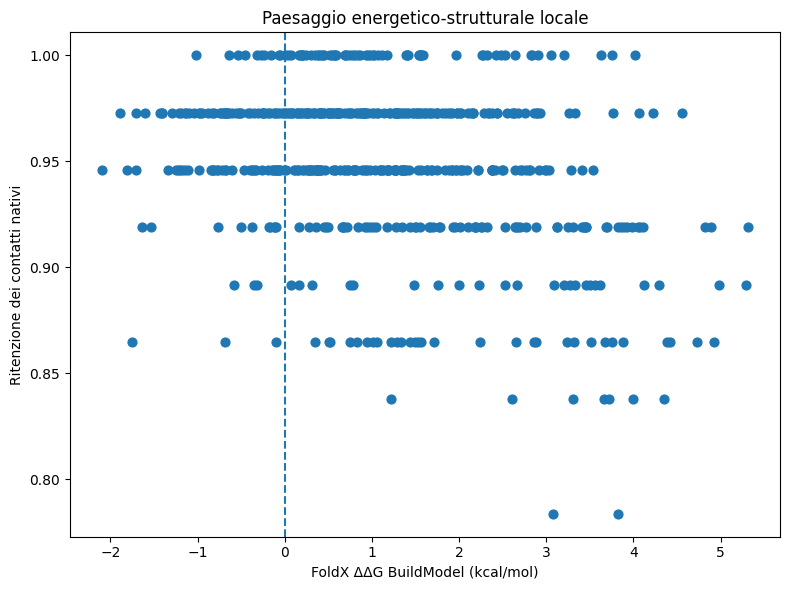

In [69]:
labeled=dataset[dataset["has_complete_foldx_label"]].copy()
if len(labeled)<=1:
    print("Nessuna variante mutante etichettata. Impostare RUN_FOLDX=True e rieseguire dalla sezione FoldX.")
else:
    display(labeled[[
        "variant_id","sequence","variant_type","mutation_labels",
        "foldx_ddG_total_kcal_mol","native_contact_recall",
        "hotspot_contact_preservation","n_atom_clashes_lt_2A",
        "oracle_target_composite_preliminary"]].sort_values(
            "oracle_target_composite_preliminary",ascending=False).head(30))
    plt.figure(figsize=(8,6))
    plt.scatter(labeled["foldx_ddG_total_kcal_mol"],labeled["native_contact_recall"],s=40)
    plt.axvline(0.0,linestyle="--")
    plt.xlabel("FoldX ΔΔG BuildModel (kcal/mol)")
    plt.ylabel("Ritenzione dei contatti nativi")
    plt.title("Paesaggio energetico-strutturale locale")
    plt.tight_layout()
    plt.savefig(REPORTS_DIR/"foldx_ddg_vs_contact_recall.png",dpi=300,bbox_inches="tight")
    plt.show()

## 17. Esportazione finale

In [70]:
FINAL_DATASET_CSV=DATASET_DIR/"clear_local_peptide_variant_dataset.csv"
LABELED_DATASET_CSV=DATASET_DIR/"clear_local_peptide_variant_dataset_labeled.csv"
CHUNK_MANIFEST_CSV=DATASET_DIR/"foldx_chunk_manifest.csv"
EXECUTION_CSV=DATASET_DIR/"foldx_execution_status.csv"
FINAL_STATUS_CSV=DATASET_DIR/"foldx_final_chunk_status.csv"
MODEL_MANIFEST_CSV=DATASET_DIR/"variant_model_manifest.csv"
METADATA_JSON=DATASET_DIR/"clear_local_dataset_metadata.json"

dataset.to_csv(FINAL_DATASET_CSV,index=False)
dataset[dataset["has_complete_foldx_label"]].to_csv(LABELED_DATASET_CSV,index=False)
chunk_manifest.to_csv(CHUNK_MANIFEST_CSV,index=False)
final_chunk_status.to_csv(FINAL_STATUS_CSV,index=False)
model_manifest.to_csv(MODEL_MANIFEST_CSV,index=False)
if not foldx_execution_status.empty:
    foldx_execution_status.to_csv(EXECUTION_CSV,index=False)

metadata={
    "seed_fragment_id":SEED_FRAGMENT_ID,"seed_sequence":SEED_SEQUENCE,
    "receptor_chain":RECEPTOR_CHAIN,"peptide_chain":PEPTIDE_CHAIN,
    "seed_start_resseq":SEED_START_RESSEQ,"seed_end_resseq":SEED_END_RESSEQ,
    "hotspot_resseqs":sorted(hotspot_resseqs),"protected_resseqs":sorted(protected_resseqs),
    "n_variants_total":int(len(dataset)),
    "n_seed":int((dataset["variant_type"]=="seed").sum()),
    "n_single":int((dataset["variant_type"]=="single").sum()),
    "n_double":int((dataset["variant_type"]=="double").sum()),
    "n_complete_labels":int(dataset["has_complete_foldx_label"].sum()),
    "foldx_chunk_size":FOLDX_CHUNK_SIZE,"foldx_executable":FOLDX_EXECUTABLE,
    "foldx_run_requested":RUN_FOLDX,
    "preliminary_target":{"foldx_ddG_weight":.50,"native_contact_recall_weight":.30,
                          "hotspot_preservation_weight":.20,"clash_penalty":.50},
    "warning":"Il target composito è preliminare e va riesaminato nel notebook 04d.",
}
METADATA_JSON.write_text(json.dumps(metadata,indent=2),encoding="utf-8")

for p in [FINAL_DATASET_CSV,LABELED_DATASET_CSV,CHUNK_MANIFEST_CSV,
          FINAL_STATUS_CSV,MODEL_MANIFEST_CSV,METADATA_JSON]:
    print("Salvato:",p.resolve())

Salvato: /Users/robertobruzzese/Desktop/venv/outputs/clear_local_peptide_dataset_04c/clear_local_peptide_variant_dataset.csv
Salvato: /Users/robertobruzzese/Desktop/venv/outputs/clear_local_peptide_dataset_04c/clear_local_peptide_variant_dataset_labeled.csv
Salvato: /Users/robertobruzzese/Desktop/venv/outputs/clear_local_peptide_dataset_04c/foldx_chunk_manifest.csv
Salvato: /Users/robertobruzzese/Desktop/venv/outputs/clear_local_peptide_dataset_04c/foldx_final_chunk_status.csv
Salvato: /Users/robertobruzzese/Desktop/venv/outputs/clear_local_peptide_dataset_04c/variant_model_manifest.csv
Salvato: /Users/robertobruzzese/Desktop/venv/outputs/clear_local_peptide_dataset_04c/clear_local_dataset_metadata.json


## 18. Report automatico e passaggio successivo

In [58]:
report=f'''# 04c — CLEAR local peptide variant dataset

## Seed
- ID: {SEED_FRAGMENT_ID}
- Sequenza: `{SEED_SEQUENCE}`
- Residui PDB: {PEPTIDE_CHAIN}:{SEED_START_RESSEQ}-{SEED_END_RESSEQ}

## Vincoli
- Hotspot: {sorted(hotspot_resseqs)}
- Hotspot protetti: {sorted(protected_resseqs)}
- Mutazioni massime: 2
- Nuove cisteine: {ALLOW_NEW_CYSTEINE}
- Introduzione di prolina: {ALLOW_PROLINE_INTRODUCTION}

## Libreria
- Totale: {len(dataset)}
- Seed: {(dataset["variant_type"]=="seed").sum()}
- Singole: {(dataset["variant_type"]=="single").sum()}
- Doppie: {(dataset["variant_type"]=="double").sum()}

## FoldX
- RUN_FOLDX: {RUN_FOLDX}
- Label complete: {dataset["has_complete_foldx_label"].sum()}
- Blocchi: {chunk_manifest["chunk_id"].nunique()}
- Blocchi completi: {final_chunk_status["complete"].sum()}

## Output
`{FINAL_DATASET_CSV}`

## Passaggio successivo
Il 04d dovrà definire formalmente il target, costruire gli split senza leakage, creare la rappresentazione a grafo e addestrare l'oracolo usato da CLEAR.
'''
REPORT_PATH=REPORTS_DIR/"04c_dataset_report.md"
REPORT_PATH.write_text(report,encoding="utf-8")
print(report)
print("Report:",REPORT_PATH.resolve())

# 04c — CLEAR local peptide variant dataset

## Seed
- ID: F0010
- Sequenza: `IGERCQYRDLK`
- Residui PDB: D:38-48

## Vincoli
- Hotspot: [39, 41, 43, 44, 45, 47]
- Hotspot protetti: [39, 41]
- Mutazioni massime: 2
- Nuove cisteine: False
- Introduzione di prolina: False

## Libreria
- Totale: 539
- Seed: 1
- Singole: 38
- Doppie: 500

## FoldX
- RUN_FOLDX: True
- Label complete: 539
- Blocchi: 11
- Blocchi completi: 11

## Output
`outputs/clear_local_peptide_dataset_04c/clear_local_peptide_variant_dataset.csv`

## Passaggio successivo
Il 04d dovrà definire formalmente il target, costruire gli split senza leakage, creare la rappresentazione a grafo e addestrare l'oracolo usato da CLEAR.

Report: /Users/robertobruzzese/Desktop/venv/outputs/clear_local_peptide_dataset_04c/reports/04c_dataset_report.md


## Interpretazione

Il file principale è:

```text
outputs/clear_local_peptide_dataset_04c/
    clear_local_peptide_variant_dataset.csv
```

Dopo l’esecuzione FoldX, il file:

```text
clear_local_peptide_variant_dataset_labeled.csv
```

conterrà le varianti utilizzabili per addestrare l’oracolo.

Prima di applicare CLEAR sarà necessario:

1. verificare la distribuzione delle label;
2. definire il target definitivo;
3. creare split train/validation/test senza leakage tra mutazioni correlate;
4. verificare la generalizzazione dell’oracolo;
5. scegliere un target controfattuale realistico.